In [2]:
import cv2
import pandas as pd
import supervision as sv

from IPython.display import Video
from typing import Dict, List, Optional, Union, Iterable, Tuple
from operator import itemgetter

import cv2
import numpy as np
import torch
from tqdm import tqdm

from inference import get_model

[09/22/26 18:49:02] WARNING  Your inference package version 1.5.0 is out of date! Please upgrade to  ]8;id=783811;file://c:\Users\zecab\.gemini\antigravity-ide\scratch\Basketball-player-tracking\.venv\Lib\site-packages\inference\core\__init__.py\__init__.py]8;;\:]8;id=783812;file://c:\Users\zecab\.gemini\antigravity-ide\scratch\Basketball-player-tracking\.venv\Lib\site-packages\inference\core\__init__.py#50\50]8;;\
                             version 1.6.2 of inference for the latest features and bug fixes by                   
                             running `pip install --upgrade inference`.                                            

ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL_YOLO_WORLD_ENABLED to False.


In [1]:
from pathlib import Path
import sys

HOME = Path("C:/Users/zecab/.gemini/antigravity-ide/scratch/Basketball-player-tracking")
if str(HOME) not in sys.path:
    sys.path.insert(0, str(HOME))

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# SOURCE_VIDEO_PATH = HOME / "data/Bad_detections_game2_1min.mp4"

SOURCE_VIDEO_PATH = HOME / "data/Bad_detections_game2_10s.mp4"

In [3]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
INFER_CONFIDENCE = 0.25  # model floor; keep low so overlapping labels reach NMS
PLAYER_MIN_CONFIDENCE = 0.4  # drop crowd/bench after NMS
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
NMS_IOU = 0.5
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID)

PLAYER_CLASS_IDS = [3, 4, 5, 6, 7]  # player, possession, jump-shot, layup, block
EVENT_CLASS_IDS = [0, 1, 4, 5, 6]  # ball, ball-in-rim, possession, jump-shot, layup
CLASS_CONFIDENCE = {
    0: 0.35,
    1: 0.90,
    4: 0.40,
    5: 0.25,
    6: 0.30,
}

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

In [4]:
import sys
from pathlib import Path

SAM2_DIR = Path(r"C:\Users\zecab\.gemini\antigravity-ide\scratch\segment-anything-2-real-time")
sys.path.insert(0, str(SAM2_DIR))

# Drop any already-imported official sam2
for name in list(sys.modules):
    if name == "sam2" or name.startswith("sam2."):
        del sys.modules[name]

from sam2.build_sam import build_sam2_camera_predictor

predictor = build_sam2_camera_predictor(
    "configs/sam2.1/sam2.1_hiera_t.yaml",
    str(SAM2_DIR / "checkpoints/sam2.1_hiera_tiny.pt"),
)

In [5]:
from __future__ import annotations

from contextlib import ExitStack, nullcontext


def _track_context():
    stack = ExitStack()
    stack.enter_context(torch.inference_mode())
    if torch.cuda.is_available():
        stack.enter_context(torch.autocast("cuda", dtype=torch.bfloat16))
    else:
        stack.enter_context(nullcontext())
    return stack


def _masks_from_logits(mask_logits, edge: float = 0.03) -> np.ndarray:
    masks = mask_logits > 0.0
    if hasattr(masks, "cpu"):
        masks = masks.cpu().numpy()
    masks = np.squeeze(np.asarray(masks)).astype(bool)
    if masks.ndim == 2:
        masks = masks[None, ...]
    return np.array(
        [
            sv.filter_segments_by_distance(
                mask, relative_distance=edge, mode="edge"
            )
            for mask in masks
        ]
    )


class SAM2Tracker:
    """Prompt SAM2, propagate within a shot, and fully reset on a camera cut."""

    def __init__(self, predictor) -> None:
        self.predictor = predictor
        self._prompted = False

    def prompt_first_frame(
        self, frame: np.ndarray, detections: sv.Detections
    ) -> sv.Detections:
        if len(detections) == 0:
            raise ValueError("detections must contain at least one box")

        if detections.tracker_id is None:
            detections.tracker_id = np.arange(1, len(detections) + 1)

        video_res_masks = None
        obj_ids = None
        with _track_context():
            self.predictor.load_first_frame(frame)
            for xyxy, obj_id in zip(detections.xyxy, detections.tracker_id):
                bbox = np.asarray([xyxy], dtype=np.float32)
                _, obj_ids, video_res_masks = self.predictor.add_new_prompt(
                    frame_idx=0,
                    obj_id=int(obj_id),
                    bbox=bbox,
                )

        self._prompted = True
        if video_res_masks is None:
            return detections

        masks = _masks_from_logits(video_res_masks)
        xyxy = sv.mask_to_xyxy(masks=masks)
        tracker_id = np.asarray(
            obj_ids if obj_ids is not None else detections.tracker_id,
            dtype=np.int32,
        )
        return sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_id)

    def propagate(self, frame: np.ndarray) -> sv.Detections:
        if not self._prompted:
            raise RuntimeError("Call prompt_first_frame before propagate")

        with _track_context():
            tracker_ids, mask_logits = self.predictor.track(frame)

        tracker_ids = np.asarray(tracker_ids, dtype=np.int32)
        masks = _masks_from_logits(mask_logits)
        xyxy = sv.mask_to_xyxy(masks=masks)
        return sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_ids)

    def reset(self) -> None:
        """Drop SAM2 memory so the next prompt_first_frame starts a new shot."""
        self._prompted = False

In [6]:
from dataclasses import dataclass, field

from sports import TeamClassifier
from src.tracking.cuts import (
    THRESHOLD_HIGH,
    THRESHOLD_LOW,
    compare_histograms,
    detect_hard_cuts,
)

try:
    from scipy.optimize import linear_sum_assignment
except ImportError:
    linear_sum_assignment = None

COLLAPSE_IOU_THRESHOLD = 0.05
COLLAPSE_COOLDOWN = 15  # skip transition frames and post-cut SAM2 warmup
COLLAPSE_STREAK = 3  # require this many low-IoU frames before a collapse reset
MAX_PLAYERS_PER_TEAM = 5
GALLERY_MATCH_THRESHOLD = 0.55  # appearance + height cost; lower is closer
TEAM_CROP_STRIDE = 30
EMBED_EMA = 0.3
HEIGHT_WEIGHT = 0.5
JERSEY_CROP_SCALE = 0.4


def detect_raw(frame: np.ndarray, class_ids=PLAYER_CLASS_IDS) -> sv.Detections:
    """Low-threshold RF-DETR. No NMS or confidence floors."""
    result = PLAYER_DETECTION_MODEL.infer(
        frame,
        confidence=INFER_CONFIDENCE,
        iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD,
    )[0]
    detections = sv.Detections.from_inference(result)
    if len(detections) == 0:
        return detections
    return detections[np.isin(detections.class_id, class_ids)]


def apply_nms(
    detections: sv.Detections,
    iou: float = NMS_IOU,
    class_agnostic: bool = True,
) -> sv.Detections:
    if len(detections) == 0:
        return detections
    return detections.with_nms(threshold=iou, class_agnostic=class_agnostic)


def keep_top1_per_class(
    detections: sv.Detections,
    class_ids=EVENT_CLASS_IDS,
) -> sv.Detections:
    if len(detections) == 0 or detections.confidence is None or detections.class_id is None:
        return detections
    keep_idx: list[int] = []
    for cid in class_ids:
        local = np.where(detections.class_id == cid)[0]
        if len(local) == 0:
            continue
        keep_idx.append(int(local[int(np.argmax(detections.confidence[local]))]))
    if not keep_idx:
        return detections[np.zeros(len(detections), dtype=bool)]
    return detections[np.array(keep_idx, dtype=int)]


def apply_class_floors(
    detections: sv.Detections,
    floors: dict[int, float] | None = None,
    default_floor: float = INFER_CONFIDENCE,
) -> sv.Detections:
    if len(detections) == 0 or detections.confidence is None or detections.class_id is None:
        return detections
    if floors is None:
        return detections[detections.confidence >= default_floor]
    keep = np.array(
        [
            float(conf) >= floors.get(int(cid), default_floor)
            for cid, conf in zip(detections.class_id, detections.confidence)
        ],
        dtype=bool,
    )
    return detections[keep]


def clean_detections(detections: sv.Detections):
    """testing.ipynb event chain: NMS → top-1 per class → class floors."""
    step1 = apply_nms(detections, class_agnostic=True)
    step2 = keep_top1_per_class(step1)
    step3 = apply_class_floors(step2, floors=CLASS_CONFIDENCE)
    return step1, step2, step3


def detect_players(frame: np.ndarray) -> sv.Detections:
    """Player bodies: infer 0.25 → class-agnostic NMS → conf >= 0.4.

    Do not run top-1 here: that would collapse ten standing players to one box.
    """
    detections = detect_raw(frame, PLAYER_CLASS_IDS)
    detections = apply_nms(detections, iou=NMS_IOU, class_agnostic=True)
    return apply_class_floors(detections, default_floor=PLAYER_MIN_CONFIDENCE)


def jersey_crops(frame: np.ndarray, detections: sv.Detections, scale: float = JERSEY_CROP_SCALE) -> list[np.ndarray]:
    if len(detections) == 0:
        return []
    boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=scale)
    return [sv.crop_image(frame, box) for box in boxes]


def median_track_det_iou(tracks: sv.Detections, dets: sv.Detections) -> float:
    if len(tracks) == 0 or len(dets) == 0:
        return 0.0
    iou = sv.box_iou_batch(tracks.xyxy, dets.xyxy)
    return float(np.median(iou.max(axis=1)))


def l2_normalize(vectors: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    vectors = np.asarray(vectors, dtype=np.float32)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / np.clip(norms, eps, None)


def _greedy_assignment(cost: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    cost = cost.copy()
    rows, cols = [], []
    while cost.size and np.isfinite(cost).any():
        r, c = np.unravel_index(np.argmin(cost), cost.shape)
        if not np.isfinite(cost[r, c]):
            break
        rows.append(int(r))
        cols.append(int(c))
        cost[r, :] = np.inf
        cost[:, c] = np.inf
    return np.asarray(rows, dtype=int), np.asarray(cols, dtype=int)


def _body_crops(frame: np.ndarray, detections: sv.Detections) -> list[np.ndarray]:
    if len(detections) == 0:
        return []
    frame_h, frame_w = frame.shape[:2]
    boxes = sv.clip_boxes(xyxy=detections.xyxy, resolution_wh=(frame_w, frame_h))
    return [sv.crop_image(frame, box) for box in boxes]


def _box_heights(detections: sv.Detections) -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0,), dtype=np.float32)
    return (detections.xyxy[:, 3] - detections.xyxy[:, 1]).astype(np.float32)


@dataclass
class PlayerGallery:
    """Global player IDs stitched across camera shots via team + appearance."""

    team_classifier: object
    max_per_team: int = MAX_PLAYERS_PER_TEAM
    match_threshold: float = GALLERY_MATCH_THRESHOLD
    next_id: int = 1
    ids: list[int] = field(default_factory=list)
    team_ids: list[int] = field(default_factory=list)
    embeddings: list[np.ndarray] = field(default_factory=list)
    heights: list[float] = field(default_factory=list)

    def _embed_and_team(self, frame: np.ndarray, detections: sv.Detections):
        jersey = jersey_crops(frame, detections)
        bodies = _body_crops(frame, detections)
        heights = _box_heights(detections)
        if not jersey or not bodies:
            empty = np.zeros((0,), dtype=int)
            return empty, np.zeros((0, 1), dtype=np.float32), heights[:0]

        jersey_feat = self.team_classifier.extract_features(jersey)
        projections = self.team_classifier.reducer.transform(jersey_feat)
        teams = np.asarray(self.team_classifier.cluster_model.predict(projections), dtype=int)
        body_feat = self.team_classifier.extract_features(bodies)
        return teams, l2_normalize(body_feat), heights

    def _cap_per_team(self, detections: sv.Detections, teams: np.ndarray):
        empty_idx = np.zeros((0,), dtype=int)
        if len(detections) == 0:
            return detections, teams, empty_idx
        confidence = (
            detections.confidence
            if detections.confidence is not None
            else np.ones(len(detections))
        )
        keep: list[int] = []
        for team in np.unique(teams):
            members = np.where(teams == team)[0]
            order = members[np.argsort(-confidence[members])]
            keep.extend(order[: self.max_per_team].tolist())
        keep_idx = np.asarray(sorted(keep), dtype=int)
        return detections[keep_idx], teams[keep_idx], keep_idx

    def assign(
        self,
        frame: np.ndarray,
        detections: sv.Detections,
        occupied_ids: set[int] | None = None,
    ) -> sv.Detections:
        if len(detections) == 0:
            detections.tracker_id = np.array([], dtype=int)
            return detections

        teams, embeds, heights = self._embed_and_team(frame, detections)
        detections, teams, keep_idx = self._cap_per_team(detections, teams)
        if len(keep_idx):
            embeds = embeds[keep_idx]
            heights = heights[keep_idx]

        n = len(detections)
        assigned = np.zeros(n, dtype=int)
        if n == 0:
            detections.tracker_id = assigned
            return detections

        occupied = {int(i) for i in (occupied_ids or set())}

        if not self.ids:
            for i in range(n):
                assigned[i] = self._mint(int(teams[i]), embeds[i], float(heights[i]))
            detections.tracker_id = assigned
            return detections

        gallery_embeds = np.stack(self.embeddings, axis=0)
        gallery_teams = np.asarray(self.team_ids, dtype=int)
        gallery_heights = np.asarray(self.heights, dtype=np.float32)
        cost = np.full((n, len(self.ids)), np.inf, dtype=np.float32)
        same_team = teams[:, None] == gallery_teams[None, :]
        cosine = embeds @ gallery_embeds.T
        denom = np.maximum(heights[:, None], gallery_heights[None, :])
        denom = np.clip(denom, 1.0, None)
        height_cost = np.abs(heights[:, None] - gallery_heights[None, :]) / denom
        cost[same_team] = (1.0 - cosine[same_team]) + HEIGHT_WEIGHT * height_cost[same_team]
        for j, gid in enumerate(self.ids):
            if int(gid) in occupied:
                cost[:, j] = np.inf

        if linear_sum_assignment is not None:
            finite = np.where(np.isfinite(cost), cost, 1e6)
            row_ind, col_ind = linear_sum_assignment(finite)
        else:
            row_ind, col_ind = _greedy_assignment(cost)

        for r, c in zip(row_ind, col_ind):
            if not np.isfinite(cost[r, c]) or cost[r, c] > self.match_threshold:
                continue
            assigned[r] = self.ids[c]
            updated = l2_normalize(
                ((1.0 - EMBED_EMA) * self.embeddings[c] + EMBED_EMA * embeds[r])[None, :]
            )[0]
            self.embeddings[c] = updated
            self.heights[c] = (1.0 - EMBED_EMA) * self.heights[c] + EMBED_EMA * float(heights[r])

        for i in range(n):
            if assigned[i] != 0:
                continue
            assigned[i] = self._mint(int(teams[i]), embeds[i], float(heights[i]))

        detections.tracker_id = assigned
        return detections

    def _mint(self, team_id: int, embedding: np.ndarray, height: float) -> int:
        gid = self.next_id
        self.next_id += 1
        self.ids.append(gid)
        self.team_ids.append(team_id)
        self.embeddings.append(embedding)
        self.heights.append(float(height))
        return gid


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
team_classifier = TeamClassifier(device=device)

crops: list[np.ndarray] = []
for sampled, frame in enumerate(
    sv.get_video_frames_generator(str(SOURCE_VIDEO_PATH), stride=TEAM_CROP_STRIDE)
):
    players = detect_players(frame)
    crops.extend(jersey_crops(frame, players))

if not crops:
    raise RuntimeError("No jersey crops found to fit TeamClassifier.")

print(f"fitting TeamClassifier on {len(crops)} jersey crops (device={device})")
team_classifier.fit(crops)
gallery = PlayerGallery(team_classifier)
print("team classifier ready")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

fitting TeamClassifier on 89 jersey crops (device=cuda)


Embedding extraction: 3it [00:02,  1.16it/s]


team classifier ready


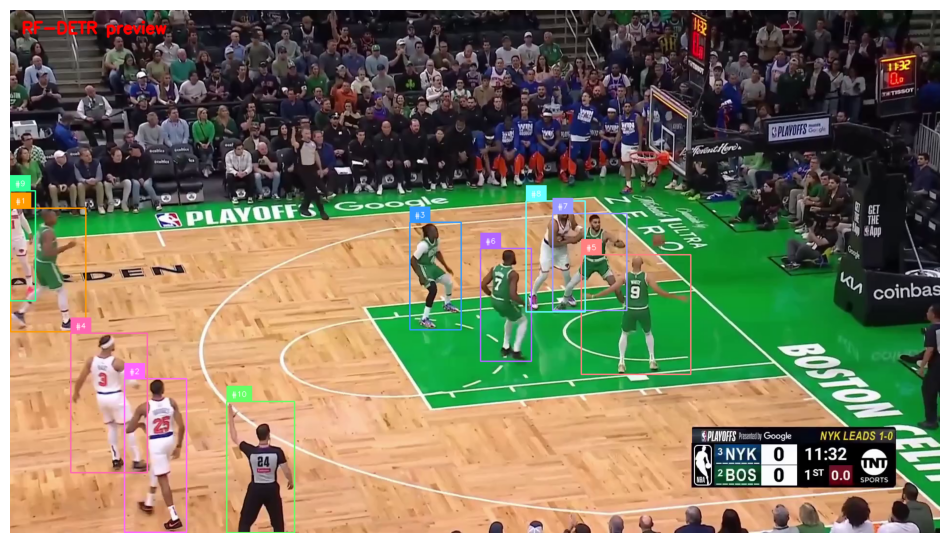

Processing video:   0%|          | 0/300 [00:00<?, ?it/s]


Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  1.77it/s]

Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  1.84it/s]

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).

Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  5.80it/s]

Embedding extraction: 0it [00:00, ?it/s]
Embedding extraction: 1it [00:00,  5.25it/s]

Skipping the post-processing step due to the error abov

In [ ]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-mask{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

mask_annotator = sv.MaskAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    opacity=0.5,
)
box_annotator = sv.BoxAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    thickness=2,
)
label_annotator = sv.LabelAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    text_thickness=1,
    text_scale=0.5,
)

tracker = SAM2Tracker(predictor)
prev_frame: np.ndarray | None = None
last_reset_idx = -COLLAPSE_COOLDOWN
collapse_streak = 0
cut_events: list[dict] = []
hist_scores: list[float] = []
ids_seen: set[int] = set()
ids_per_frame: list[int] = []


def _annotate(frame: np.ndarray, detections: sv.Detections, banner: str | None = None) -> np.ndarray:
    annotated = frame.copy()
    if len(detections) > 0 and detections.tracker_id is not None:
        if detections.mask is not None:
            annotated = mask_annotator.annotate(scene=annotated, detections=detections)
        annotated = box_annotator.annotate(scene=annotated, detections=detections)
        labels = [f"#{int(tid)}" for tid in detections.tracker_id]
        annotated = label_annotator.annotate(
            scene=annotated, detections=detections, labels=labels
        )
    if banner:
        cv2.putText(
            annotated,
            banner,
            (24, 48),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.1,
            (0, 0, 255),
            3,
            cv2.LINE_AA,
        )
    return annotated


def _reinit(frame: np.ndarray, detections: sv.Detections) -> sv.Detections:
    tracker.reset()
    if len(detections) == 0:
        return detections
    prompted = gallery.assign(frame, detections, occupied_ids=set())
    if len(prompted) == 0:
        return prompted
    return tracker.prompt_first_frame(frame, prompted)


first_frame = next(sv.get_video_frames_generator(str(SOURCE_VIDEO_PATH),start=30))
preview = detect_players(first_frame)
if preview.tracker_id is None:
    preview.tracker_id = np.arange(1, len(preview) + 1)
sv.plot_image(_annotate(first_frame, preview, banner="RF-DETR preview"))


def callback(frame: np.ndarray, index: int) -> np.ndarray:
    global prev_frame, last_reset_idx, collapse_streak

    detector_players = detect_players(frame)
    hist_score = 1.0
    is_cut = False
    if prev_frame is not None:
        hist_score, _, _ = compare_histograms(frame, prev_frame)
        is_cut = detect_hard_cuts(index, frame, prev_frame)
    hist_scores.append(hist_score)
    banner = None
    players: sv.Detections
    cooled = index - last_reset_idx >= COLLAPSE_COOLDOWN

    if not tracker._prompted:
        reason = "cut" if is_cut else "init"
        players = _reinit(frame, detector_players)
        collapse_streak = 0
        if tracker._prompted or is_cut:
            last_reset_idx = index
            cut_events.append({"frame_idx": index, "reason": reason, "score": hist_score})
            banner = f"{reason.upper()}  hist={hist_score:.2f}"
    elif is_cut and cooled:
        players = _reinit(frame, detector_players)
        collapse_streak = 0
        last_reset_idx = index
        cut_events.append({"frame_idx": index, "reason": "cut", "score": hist_score})
        banner = f"CUT  hist={hist_score:.2f}"
    else:
        players = tracker.propagate(frame)
        iou_score = median_track_det_iou(players, detector_players)
        if cooled and len(detector_players) > 0 and iou_score < COLLAPSE_IOU_THRESHOLD:
            collapse_streak += 1
        else:
            collapse_streak = 0
        if collapse_streak >= COLLAPSE_STREAK:
            players = _reinit(frame, detector_players)
            collapse_streak = 0
            last_reset_idx = index
            cut_events.append(
                {"frame_idx": index, "reason": "collapse", "score": iou_score}
            )
            banner = f"COLLAPSE  iou={iou_score:.2f}"

    if players.tracker_id is not None and len(players) > 0:
        ids_seen.update(int(tid) for tid in players.tracker_id)
        ids_per_frame.append(len(ids_seen))
    else:
        ids_per_frame.append(len(ids_seen))

    prev_frame = frame
    return _annotate(frame, players, banner=banner)


sv.process_video(
    source_path=str(SOURCE_VIDEO_PATH),
    target_path=str(TARGET_VIDEO_PATH),
    callback=callback,
    show_progress=True,
)


In [ ]:
import subprocess
from imageio_ffmpeg import get_ffmpeg_exe
from IPython.display import Video, display

print("raw:", TARGET_VIDEO_PATH.exists(), TARGET_VIDEO_PATH)
ffmpeg = get_ffmpeg_exe()
subprocess.run(
    [
        ffmpeg,
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(TARGET_VIDEO_PATH),
        "-vcodec",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        "-crf",
        "28",
        str(TARGET_VIDEO_COMPRESSED_PATH),
    ],
    check=True,
)
print("compressed:", TARGET_VIDEO_COMPRESSED_PATH.exists(), TARGET_VIDEO_COMPRESSED_PATH)
display(Video(str(TARGET_VIDEO_COMPRESSED_PATH), embed=True, width=720))